## Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Auxiliary Classes/Functions

In [7]:
class KNN:
    def __init__(self, distance="euclidian"):
        self.k_neighbors = 3
        self._distance_validation(distance)

    def _distance_validation(self, distance):
        list_of_distances = ["euclidian", "manhattan"]
        if not (isinstance(distance, str)):
            raise TypeError("Distance must be a string input.")
        elif distance not in list_of_distances:
            raise ValueError(
                f"The distance must be one of the following options: {list_of_distances}."
            )
        else:
            self.distance = distance

    def _k_neighbors_validation(self, k_neighbors):
        if not (isinstance(k_neighbors, int)):
            raise TypeError(
                "The number of neighbors (k_neighbors) must be of integer type."
            )
        elif k_neighbors <= 0:
            raise ValueError(
                "The number of neighbors (k_neighbors) must be greater than 0."
            )
        else:
            self.k_neighbors = k_neighbors

    def set_k_neighbors(self, k_neighbors):
        self._k_neighbors_validation(k_neighbors)

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def _predict_single(self, x_test):
        if self.distance == "euclidian":
            dists = np.sqrt(np.sum((self.X_train - x_test) ** 2, axis=1))
        else:
            dists = np.sqrt(np.sum(np.abs(self.X_train - x_test), axis=1))

        k_nearest_indices = np.argsort(dists)[: self.k_neighbors]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        prediction = np.mean(k_nearest_labels)
        return prediction

    def predict(self, X_test):
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)


def elbow_plot(X_train, X_test, y_train, y_test):
    k_list = range(1, len(X_train))
    r2_list = []
    mse_list = []

    for k in k_list:
        model = KNN()
        model.set_k_neighbors(k)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_list.append(r2_score(y_test, y_pred))
        mse_list.append(mean_squared_error(y_test, y_pred))

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax1.plot(k_list, r2_list, color="blue", marker="o")
    ax1.set_ylabel("Coefficient of Determination (R²)", fontsize=12, color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(k_list, mse_list, color="red", marker="o")
    ax2.set_ylabel("Mean Squared Error (MSE)", fontsize=12, color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    plt.title("Elbow Plot", fontsize=16)
    ax1.set_xlabel("Number of Neighbors (k)", fontsize=12)

    plt.grid(True)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    plt.tight_layout()

## Data Generation

In [8]:
np.random.seed(42)
X = np.sort(10 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(100) * 0.2

print(f"The size of X is {len(X)}.")
print(f"The size of y is {len(y)}.")

# X_train, X_test = X[:int(0.8*len(X))], X[int(0.8*len(X)):]
# y_train, y_test = y[:int(0.8*len(y))], y[int(0.8*len(y)):]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

The size of X is 100.
The size of y is 100.


## Model

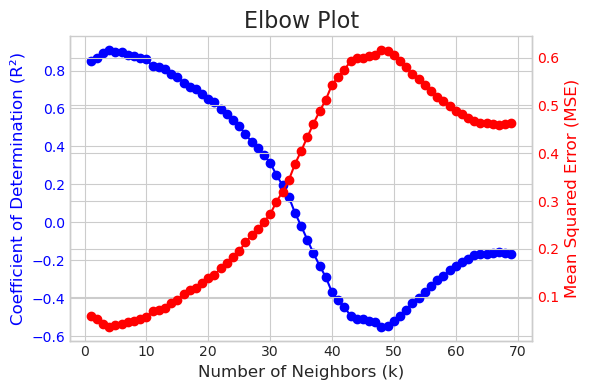

In [9]:
elbow_plot(X_train, X_test, y_train, y_test)

k = 4

model = KNN()
model.set_k_neighbors(k)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Plot

Results for k = 4:
- Mean Squared Error (MSE): 0.0368
- Coefficient of Determination (R²): 0.9074


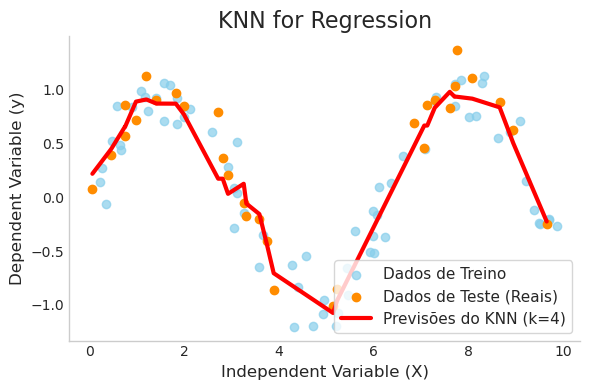

In [10]:
# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Results for k = {k}:")
print(f"- Mean Squared Error (MSE): {mse:.4f}")
print(f"- Coefficient of Determination (R²): {r2:.4f}")

# Plot
sort_axis = np.argsort(X_test.ravel())
X_test_sorted = X_test[sort_axis]
y_pred_sorted = y_pred[sort_axis]

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(6, 4))

plt.scatter(X_train, y_train, color="skyblue", label="Dados de Treino", alpha=0.7)
plt.scatter(X_test, y_test, color="darkorange", label="Dados de Teste (Reais)")
plt.plot(
    X_test_sorted,
    y_pred_sorted,
    color="red",
    linewidth=3,
    label=f"Previsões do KNN (k={k})",
)

# Chart Settings
plt.title("KNN for Regression", fontsize=16)
plt.xlabel("Independent Variable (X)", fontsize=12)
plt.ylabel("Dependent Variable (y)", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()